In [401]:
### importing the required libraries
using CSV
using DataFrames
using Statistics
using Plots

In [402]:
module Read
    include("Read_data_files.jl")
end

module Check
    include("Check_files_exist.jl")
end

Main.Check

In [403]:
### change this to the job id for the experiment you want to analyze
## or the name you want to give the folder where all the extracted data files will be stored
JOB_ID = 67133122
### make sure to write dispersal parameters as floats to keep file name consistent ###

## vary these for different dispersal scenarios
gamma = 2.0    # dispersal rate from release site to household
rho = 0.33      # rate visit the households
tau = 0.33      # rate leave the households
alpha = 0.1     # dispersal rate of females moving from household directly to another household

num_simulations = 100  # number of realisations of SSA to run, 10,000 is a good number for the paper
rel_type = "relcom"

"relcom"

In [404]:
# Define parameters dictionary
fem_w0 = 0  # how many wildtypes and infected mosquitoes starting off with
male_w0 = 0
fem_m0 = 8
male_m0 = 8
m_free0 = 0 # no. of free wild-type
w_free0 = 0 # no. of free Wolbachia

# model parameters
phi = 0.85      # wolbachia fitness effect on birth rate
K = 30          # carrying capacity of mosquitoes per household
d = 12/100      # death rate of mosquitoes
k = 0.3         # larval density parameter
h = 0.19*100^k  # larval density parameter
b = 0.54        # per capita birth rate of mosquitoes (wildtypes)
H = 100         # number of households
u = 1           # vertical transmission probability
v = 1           # CI effect, proportion of non-viable offspring from infected male and wildtype female birth

rel_t = 150   # initial release time
delta_rel = 0 # time in days between releases, currently set to a single release inside the SSA code
## remember this is per household for the household releases so should use smaller release numbers
## currently set for community wide release
rel_size = 8*H # total number of Wolbachia-infected mosquitoes released into the community

t_start = 0    
t_end = 1000   # start time and end time (days) of simulation

result_length = length(t_start:t_end) # number of time points to store results
weeks = round(Int,result_length/7)    # number of weeks to store results

parameters = Dict(           # dictionary of parameters
    :fem_m0 => fem_m0,
    :male_m0 => male_m0,
    :fem_w0 => fem_w0,
    :male_w0 => male_w0,
    :m_free0 => m_free0,
    :w_free0 => w_free0,
    :rho => rho,
    :phi => phi,
    :b => b,
    :K => K,
    :d => d,
    :h => h,
    :k => k,
    :u => u,
    :v => v,
    :tau => tau,
    :H => H,
    :t_start => t_start,
    :t_end => t_end,
    :seed => 1234,
    :delta_rel => delta_rel,
    :rel_size => rel_size,
    :gamma => gamma,
    :alpha => alpha,
    :rel_t => rel_t
)

Dict{Symbol, Real} with 25 entries:
  :b        => 0.54
  :alpha    => 0.1
  :rel_size => 800
  :gamma    => 2.0
  :m_free0  => 0
  :rho      => 0.33
  :t_start  => 0
  :h        => 0.756404
  :rel_t    => 150
  :male_w0  => 0
  :fem_m0   => 8
  :K        => 30
  :phi      => 0.85
  :fem_w0   => 0
  :d        => 0.12
  :k        => 0.3
  :v        => 1
  :u        => 1
  :male_m0  => 8
  ⋮         => ⋮

In [405]:
## Read in the total wildtype and Wolbachia-infected mosquito populations data, 
## as well as free population only versions
par_dict = Dict(
    :rho => rho,
    :tau => tau,
    :alpha => alpha,
    :gamma => gamma,
    :rel_type => rel_type,
    :H => H,
    :rel_size => rel_size,
    :rel_t => rel_t
)

m_array, w_array, free_m_array, free_w_array = Read.read_data(par_dict, JOB_ID)

([1600.0 1600.0 … 1600.0 1600.0; 1593.0 1634.0 … 1626.0 1617.0; … ; 1835.0 1889.0 … 1824.0 1959.0; 1844.0 1878.0 … 1811.0 1980.0], [0.0 0.0 … 0.0 0.0; 0.0 0.0 … 0.0 0.0; … ; 0.0 0.0 … 0.0 0.0; 0.0 0.0 … 0.0 0.0], [0.0 0.0 … 0.0 0.0; 210.0 195.0 … 179.0 180.0; … ; 368.0 423.0 … 361.0 423.0; 365.0 420.0 … 375.0 414.0], [0.0 0.0 … 0.0 0.0; 0.0 0.0 … 0.0 0.0; … ; 0.0 0.0 … 0.0 0.0; 0.0 0.0 … 0.0 0.0])

In [406]:
alpha_str, gamma_str, rho_str, tau_str = Read.str_convert(alpha, gamma, rho, tau)

sum_array, ct = Check.check_file_exist(alpha_str, gamma_str, rho_str, tau_str, H, rel_t, rel_size, rel_type, num_simulations, JOB_ID)

# Compute the mean array
# this gives the mean over all sims for each household
if ct > 0
    mean_array_2 = sum_array ./ ct
    println("Mean array computed successfully.")
else
    println("No valid data files found.")
end

Mean array computed successfully.


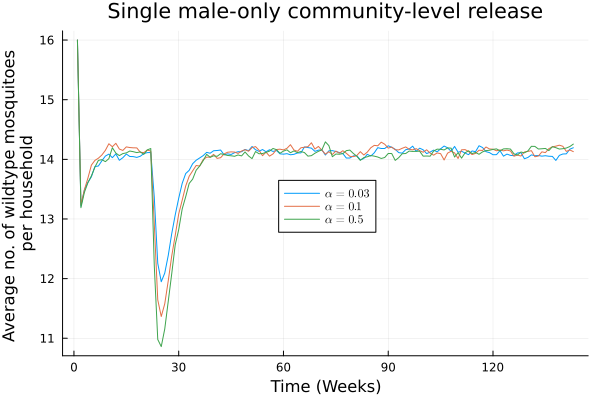

In [407]:
# Assuming mean_array_033 and mean_array_015 are already defined
# Plot the first line
p = plot(mean(mean_array_015, dims=2), xlabel="Time (Weeks)", ylabel="Average no. of wildtype mosquitoes 
per household",
    titlefont=font(14), label="\$\\alpha=0.03\$")

# Add the second line to the same plot
plot!(p, mean(mean_array_033, dims=2), label="\$\\alpha=0.1\$")

plot!(p, mean(mean_array_2, dims=2), label="\$\\alpha=0.5\$")
plot!(p, title="Single male-only community-level release", legend=:topleft)

# Set the x and y limits
#plot!(p, xlim=(0, 90))
#plot!(p, ylim=(0, 15))
plot!(p, legend=(0.5,0.5))

# Save the plot
#savefig(p, "wild_per_house_alphas_$(gamma_str)_$(rho_str)_$(tau_str)_$(H)__$(rel_t)_$(rel_size)_$(rel_type).pdf")
# Display the plot
p

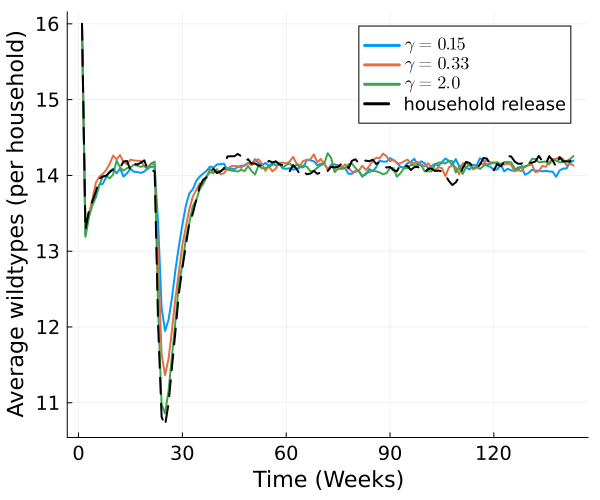

In [411]:
# Assuming mean_array_033 and mean_array_015 are already defined
# Plot the first line
p = plot(mean(mean_array_015, dims=2), xlabel="Time (Weeks)", ylabel="Average wildtypes (per household)",
    titlefont=font(14), label="\$\\gamma=0.15\$",
    size = (600, 500),
    guidefont = font(15), 
    tickfont = font(13),
    grid = true,
    linewidth=2)

# Add the second line to the same plot
plot!(p, mean(mean_array_033, dims=2), label="\$\\gamma=0.33\$",
size = (600, 500),
    guidefont = font(15), 
    tickfont = font(13),
    grid = true,
    linewidth=2)

plot!(p, mean(mean_array_2, dims=2), label="\$\\gamma=2.0\$",
size = (600, 500),
    guidefont = font(15), 
    tickfont = font(13),
    grid = true,
    linewidth=2)

plot!(p, mean(mean_array_h, dims=2), label="household release", linecolor=:black, linestyle=:dash,
size = (600, 500),
    guidefont = font(15), 
    tickfont = font(13),
    grid = true,
    linewidth=2,
    legendfont=font(12))

# Set the x and y limits
#plot!(p, xlim=(0, 90))
#plot!(p, ylim=(0, 15))

# Save the plot
savefig(p, "wild_per_house_01_gammas_033_033_100__150_16_relhhold.pdf")

# Display the plot
p
#print("wild_per_house_$(alpha_str)_gammas_$(rho_str)_$(tau_str)_$(H)__$(rel_t)_$(rel_size)_$(rel_type).pdf")